In [122]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [123]:
df=pd.read_csv('indian_engineering_student_placement.csv')

In [124]:
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,4,6,3,6.1,2,No,Low,Tier 2,Yes,High
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium


In [125]:
df.tail()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
4995,4996,Female,IT,10.00,90.4,98.3,0,3.7,75.3,6,...,5,4,2,7.3,2,No,Medium,Tier 3,Yes,Low
4996,4997,Male,IT,7.76,74.3,72.6,2,6.3,72.3,4,...,4,3,2,7.8,6,No,Low,Tier 1,Yes,Low
4997,4998,Male,IT,7.79,64.0,71.2,2,2.0,63.8,6,...,4,6,2,6.1,5,Yes,Low,Tier 2,No,Medium
4998,4999,Female,ECE,8.76,74.3,74.0,0,5.1,72.0,6,...,4,4,5,9.0,10,No,Medium,Tier 2,Yes,High
4999,5000,Male,CSE,9.45,85.6,80.0,0,2.8,63.4,8,...,4,6,2,7.8,1,No,Low,Tier 1,No,High


In [126]:
df.isna().sum()

,0
Student_ID,0
gender,0
branch,0
cgpa,0
tenth_percentage,0
twelfth_percentage,0
backlogs,0
study_hours_per_day,0
attendance_percentage,0
projects_completed,0


In [127]:
df['placement_status'] = (
    (df['cgpa'] >= 8.0) &
    (df['backlogs'] == 0) &
    (df['internships_completed'] >= 2) &
    (df['communication_skill_rating'] >= 3) &
    (df['coding_skill_rating'] >= 3)
).astype(int)

df['placement_status'].value_counts()

,count
placement_status,
0,3892
1,1108


In [128]:
df.describe()



,Student_ID,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,placement_status
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,8.283798,74.537400,74.543060,0.343600,4.041120,72.041560,5.529400,2.132600,3.728600,3.025400,4.116400,3.704200,2.836000,6.955000,6.020200,0.221600
std,1443.520003,1.008391,10.266752,10.244481,0.612547,1.967754,7.720029,2.053772,1.143713,1.278464,1.412358,0.716208,1.603252,1.781724,1.147881,2.851213,0.415365
min,1.000000,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,1250.750000,7.610000,67.400000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,0.000000
50%,2500.500000,8.320000,74.700000,74.800000,0.000000,4.000000,72.050000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,0.000000
75%,3750.250000,9.020000,82.000000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000,0.000000
max,5000.000000,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,1.000000


In [129]:
df.fillna(df.median(numeric_only=True), inplace=True)


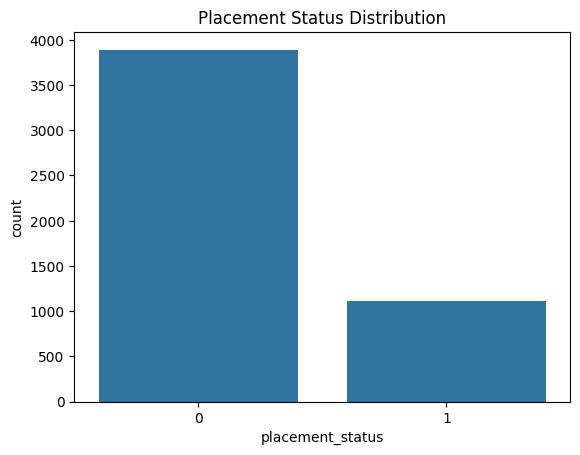

In [130]:
sns.countplot(x='placement_status', data=df)
plt.title("Placement Status Distribution")
plt.show()


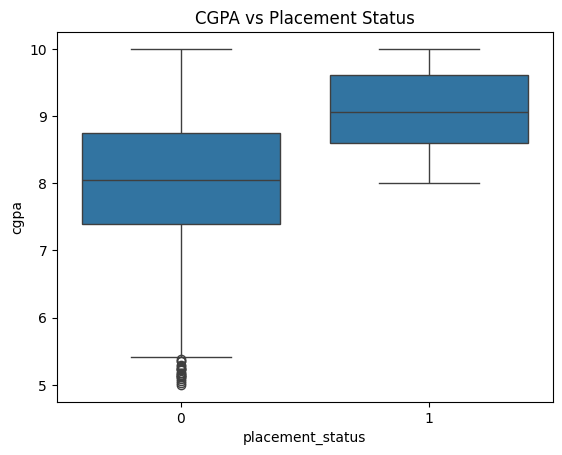

In [131]:
sns.boxplot(x='placement_status', y='cgpa', data=df)
plt.title("CGPA vs Placement Status")
plt.show()


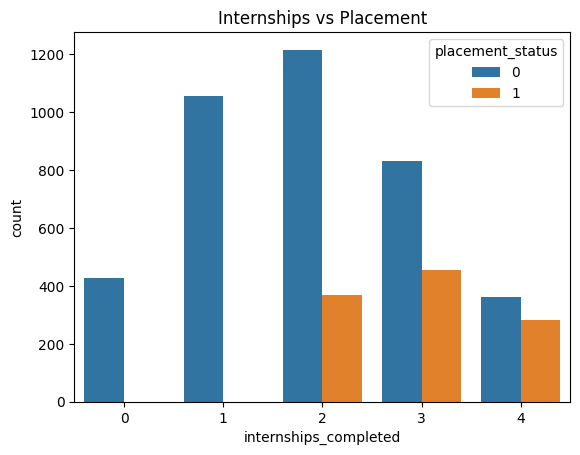

In [132]:
sns.countplot(x='internships_completed', hue='placement_status', data=df)
plt.title("Internships vs Placement")
plt.show()


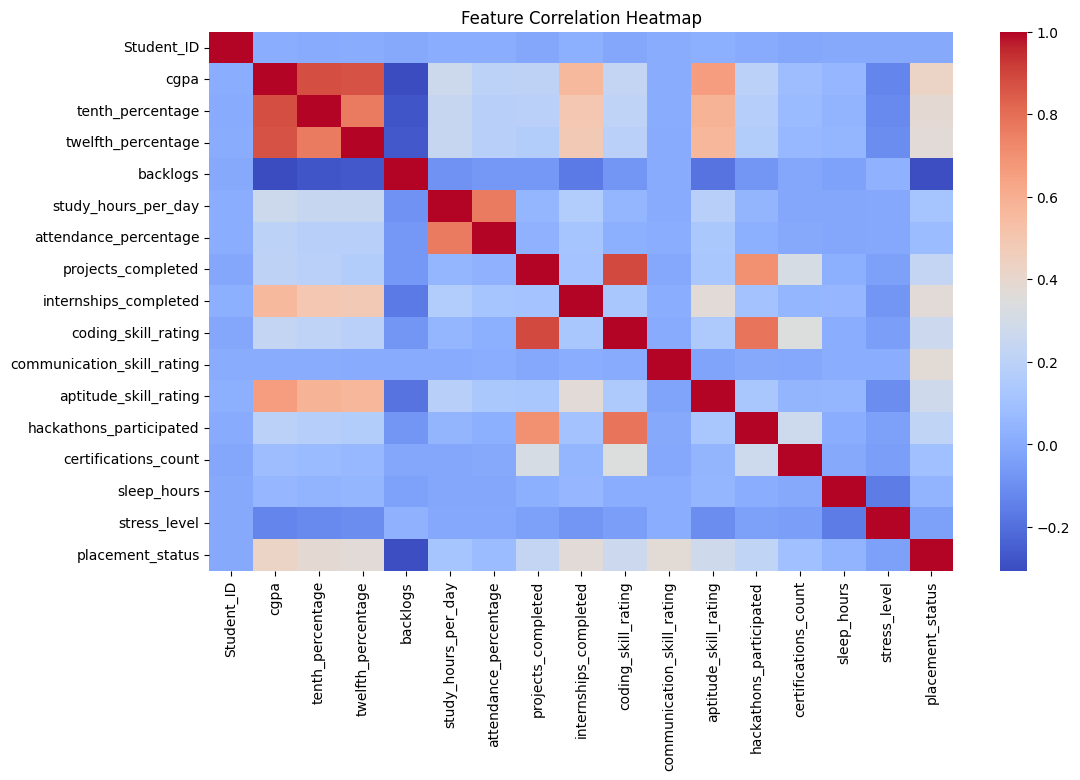

In [133]:
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [134]:
df_encoded = pd.get_dummies(df, drop_first=True)


In [135]:
X = df_encoded.drop('placement_status', axis=1)
y = df_encoded['placement_status']


In [136]:
from sklearn.model_selection import train_test_split
# train_test_split()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [137]:
from sklearn.linear_model import LogisticRegression
le = LogisticRegression()
le.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [138]:
y_pred_le = le.predict(X_test)

In [139]:
from sklearn.ensemble import RandomForestClassifier
rfc= RandomForestClassifier()
rfc.fit(X_train,y_train)

RandomForestClassifier()

In [140]:
y_pred_rfc = rfc.predict(X_test)

In [141]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train,y_train)

DecisionTreeClassifier()

In [142]:
y_pred_dtc = dtc.predict(X_test)

In [143]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [144]:
y_pred_knn = knn.predict(X_test)

In [145]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": le,
    "Decision Tree": dtc,
    "Random Forest": rfc,
    "KNN": knn,
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"{name}: {accuracy_score(y_test, y_pred):.4f}")


Logistic Regression: 0.8660
Decision Tree: 1.0000
Random Forest: 0.9990
KNN: 0.7470


In [146]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rfc))
print(classification_report(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_dtc))
print(classification_report(y_test, y_pred_le))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       790
           1       1.00      1.00      1.00       210

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

              precision    recall  f1-score   support

           0       0.82      0.87      0.85       790
           1       0.36      0.27      0.31       210

    accuracy                           0.75      1000
   macro avg       0.59      0.57      0.58      1000
weighted avg       0.72      0.75      0.73      1000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       790
           1       1.00      1.00      1.00       210

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

              preci

In [147]:
import pickle

with open("placement_model.pkl", "wb") as file:
    pickle.dump(rfc, file)
